In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler # Label Encoder to encode the classes from strings to tensors
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

from torchvision import models   # pretrained models in PyTorch library

In [2]:
# Importing Data

train_df = pd.read_csv("../data/archive/train.csv",)
val_df = pd.read_csv("../data/archive/val.csv",)

data_df = pd.concat([train_df, val_df], axis=0, ignore_index=True)
data_df['image:FILE'] = "../data/archive/" + data_df['image:FILE']  #updating the file location to match excat folder

print(f"The shape of datafram is {data_df.shape}")
print()
data_df.head()


The shape of datafram is (1167, 2)



,image:FILE,category
0,../data/archive/train/healthy/healthy_train.98...,0
1,../data/archive/train/healthy/healthy_train.14...,0
2,../data/archive/train/healthy/healthy_train.30...,0
3,../data/archive/train/healthy/healthy_train.30...,0
4,../data/archive/train/healthy/healthy_train.40...,0


## Data Inspection

In [3]:
print(f"The class are {data_df['category'].unique()} ")
print(f"Classes ditrubution are:")
data_df['category'].value_counts()

The class are [0 1 2] 
Classes ditrubution are:


category
2    393
1    389
0    385
Name: count, dtype: int64

# Spliting Data
 We are using the sample method to split the data

- training 70%
- testing 30%

In [4]:
train = data_df.sample(frac=0.7,random_state=7)
test = data_df.drop(train.index)

## Preprocessing Objects 
- use lable encoder to convert the texr to number
- Then create an Image transformer Object, resize the image, convert to tensors of floating type. 

In [5]:
label_encoder = LabelEncoder()

# Transform all images into one clear format
transform = transforms.Compose([
            transforms.Resize((128,128)), # resize and accept tuple with hieght and width
            transforms.ToTensor(),    #conver to tensor
            transforms.ConvertImageDtype(torch.float) # after tensor make change datatype to make it standard
])

In [6]:
## Custom Dataset Class

class Customeimagedataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.fit_transform(dataframe['category']))

    def __len__(self):
        return self.dataframe.shape[0]   #get the length do not use len

    def __getitem__(self,idx):     #idx use for index
        image_path = self.dataframe.iloc[idx,0]
        label = self.labels[idx]
        
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = (self.transform(image)/255)

        return image, label   




In [7]:
# Creating Dataset
train_dataset = Customeimagedataset(dataframe= train,transform=transform)
test_dataset = Customeimagedataset(test, transform)

## Visualize Images
This cell is optional and will not affect the model accuracy. Here we are just visualizing 9 random images using matplotlib package.

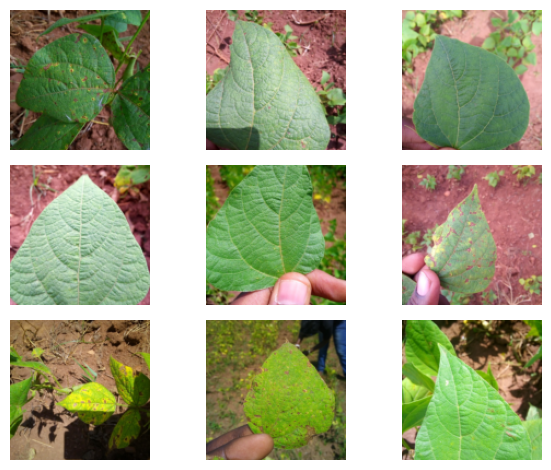

In [14]:
nrows = 3
ncols = 3

fig, ax = plt.subplots(nrows,ncols)

# We are getting random image form train dataset
for row in range(nrows):
    for col in range(ncols):
        image = train_dataset[np.random.randint(0,train_dataset.__len__())][0]   #get the random index of imgae tensor of the batch
        ax[row,col].imshow((image*255.0).squeeze().permute(1,2,0)) # as our class may have batch no so we are removing that using squeez
        ax[row, col].axis('off')

plt.tight_layout()
plt.show()

In [15]:
# Hyperparameter
LR = 1e-3
BATCH_SIZE = 4
EPOCHS = 15

train_loader = DataLoader(train_dataset, batch_size= BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [16]:
#using prefined Googlenet models

googlenet_model = models.googlenet(weights='DEFAULT')

for param in googlenet_model.parameters():
  param.requires_grad = True

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /home/malik/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100.0%


In [18]:
googlenet_model.fc  #fc--> Fully connected

Linear(in_features=1024, out_features=1000, bias=True)

In [20]:
# create fcnn
num_class = len(data_df['category'].unique())
googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_class)

In [21]:
# Define the loss function and Optimizer

criterion = nn.CrossEntropyLoss() # Cross Entropy Loss
optimizer = Adam(googlenet_model.parameters(),lr=LR)# Adam optimizer

In [22]:
total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0

  for (inputs, labels) in train_loader:
    optimizer.zero_grad()
    outputs = googlenet_model(inputs)
      
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
  print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_acc_train)/train_dataset.__len__() * 100, 4)}%')
  print()

Epoch 1/15, Train Loss: 1.7845 Train Accuracy 61.4443%

Epoch 2/15, Train Loss: 1.6809 Train Accuracy 66.7075%

Epoch 3/15, Train Loss: 1.5728 Train Accuracy 67.1971%

Epoch 4/15, Train Loss: 1.544 Train Accuracy 69.645%

Epoch 5/15, Train Loss: 1.4007 Train Accuracy 70.0122%

Epoch 6/15, Train Loss: 1.4134 Train Accuracy 72.705%

Epoch 7/15, Train Loss: 1.3967 Train Accuracy 70.9914%

Epoch 8/15, Train Loss: 1.1777 Train Accuracy 77.1114%

Epoch 9/15, Train Loss: 1.0999 Train Accuracy 79.3146%

Epoch 10/15, Train Loss: 1.0608 Train Accuracy 80.661%

Epoch 11/15, Train Loss: 1.1781 Train Accuracy 76.7442%

Epoch 12/15, Train Loss: 1.0722 Train Accuracy 82.6193%

Epoch 13/15, Train Loss: 0.9451 Train Accuracy 82.2521%

Epoch 14/15, Train Loss: 0.9957 Train Accuracy 81.6401%

Epoch 15/15, Train Loss: 0.7041 Train Accuracy 87.2705%



In [23]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for indx, (input, labels) in enumerate(test_loader):

    prediction = googlenet_model(input)

    acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()
    total_acc_test += acc

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__())*100, 2)}%")
     

Accuracy Score is: 83.43%


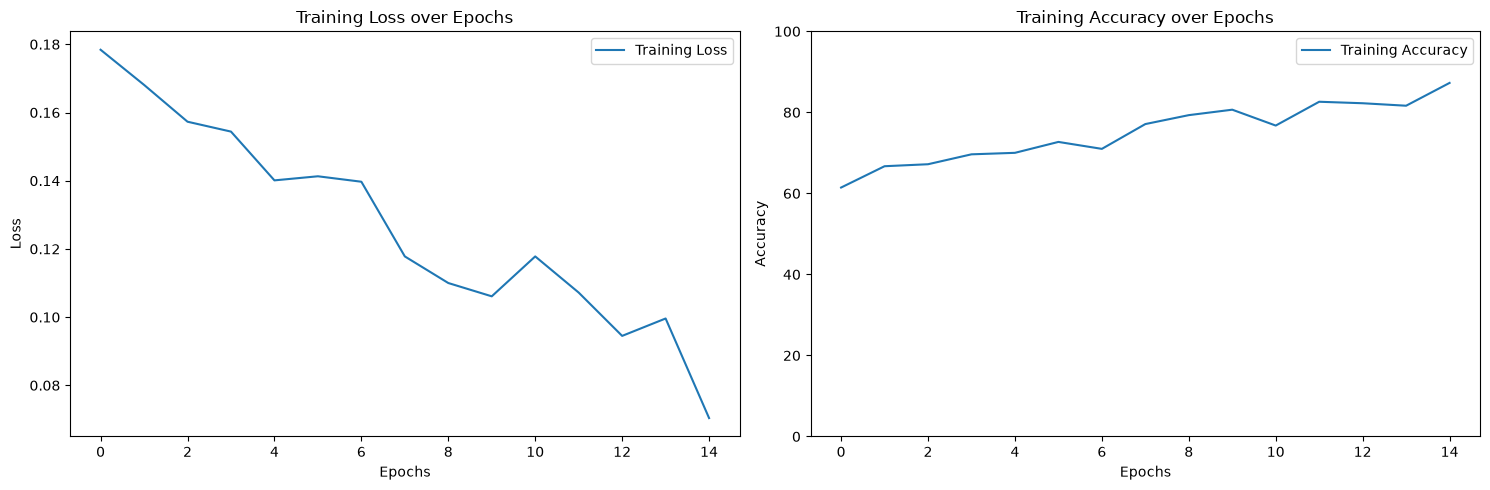

In [24]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].set_title('Training Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[1].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].set_title('Training Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()